<a href="https://colab.research.google.com/github/nicolastibata/MINE_4206_AML_202610/blob/main/labs/lab_3/MINE_4206_AML_202610_L3_S2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202520/blob/main/docs/images/logo.png?raw=true)


# **Laboratorio 3 - Sesión 2: Naive Bayes**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Introducción de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación y Modelamiento](#scrollTo=kG8XHROzvuEH&line=1&uniqifier=1)<br>
[3. Preguntas](#scrollTo=HnWtjBcSv3yG&line=1&uniqifier=1)<br>


### **Contexto y Objetivos**

**Problema**
- En este problema queremos ver el procesamiento y representación de textos para su clasificación con Naive Bayes.

**Objetivos**
1. Explorar conceptos como BoW, TF-IDF, Tokenización, etc...
2. Procesar la información en matrices dispersas para el entrenamiento del modelo de clasificación.
3. Realizar una búsqueda de hiperparametros con Naive Bayes y parametros del preprocesamiento de los documentos.


Los datos se encuentran acá: [20newsgroups](https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html)

### **1. Introducción a los datos**

In [33]:
import pandas as pd
import numpy as np
# dataset
from sklearn.datasets import fetch_20newsgroups
# Modelamiento
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
# Procesamiento de textos
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [2]:
# Definimos las categorías
categories = ['sci.space', 'rec.autos', 'alt.atheism']
# Descargamos el dataset
raw_data = fetch_20newsgroups(subset='all', categories=categories,
                             remove=('headers', 'footers', 'quotes'))

# Creamos un DataFrame para que sea más fácil de manipular
df = pd.DataFrame({'texto': raw_data.data, 'clase': raw_data.target})

# Limpiamos filas que hayan quedado vacías tras la remoción de headers/footers
df = df[df['texto'].str.strip() != ""]

print(f"Total de documentos cargados: {len(df)}")
df.head()

Total de documentos cargados: 2671


,texto,clase
0,"\nTammy, is this all explicitly stated in the ...",0
1,"\nSo what do we have now, an integral over pai...",0
2,\nPerhaps because you just made it up?,0
3,Archive-name: space/astronaut\nLast-modified: ...,2
4,I test drove a Mazda 626 LX this past weekend ...,1


In [3]:
# Count the mean of characters for each texto in the column
print(f"Promedio de chars: {df['texto'].apply(lambda x: len(x)).mean()}")
# Count the values for each clase in the column
print(f"\nDistribución de clases:\n{df['clase'].value_counts()}")

Promedio de chars: 1044.0760014975665

Distribución de clases:
clase
2    955
1    937
0    779
Name: count, dtype: int64


> Nuestro dataset consiste de 2671 documentos con un promedio de longitud de 1044 caracteres, y sus clases están balanceadas, sin embargo en el split usaremos stratify.

### **2. Preparación y Modelamiento**

#### **Preparación**

La preparación de textos consiste en 3 pasos importantes; Limpieza, Representación (BoW o TF-IDF) y Matriz Sparse.

##### **2.1. Limpieza: Tokenización y Stemming**

Antes de contar las palabras, debemos estandarizarlas y mantenerlas en su raíz.
- **Tokenización**: Dividir el texto en palabras inidividuales.
- **Stemming**: Convertir las palabras a su raíz semántico (ej. "running" -> "run").

In [4]:
# Veamos un ejemplo
nltk.download('punkt_tab')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

ejemplo = "The rockets are launching into space"
tokens = word_tokenize(ejemplo.lower())

print(f"Original: {ejemplo}")
print(f"Tokens: {tokens}")
print(f"Stemming: {[stemmer.stem(t) for t in tokens]}")


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original: The rockets are launching into space
Tokens: ['the', 'rockets', 'are', 'launching', 'into', 'space']
Stemming: ['the', 'rocket', 'are', 'launch', 'into', 'space']


**¿Para qué nos sirve el Stemming en Machine Learning?**

Si dejamos las palabras tal cual, el modelo trataría a "rocket" (singular) y "rockets" (plural) como dos columnas distintas en nuestra matriz.

Al aplicar Stemming, unificamos ambas en la raíz rocket. Esto tiene dos beneficios principales:

- Reducción de dimensionalidad: Menos columnas en nuestra matriz dispersa.
- Densidad de información: Agrupamos el significado de palabras similares en una sola característica.

Ahora aplicaremos esto a nuestro dataset...

In [5]:
def limpiar_texto(texto):
    tokens = word_tokenize(texto.lower())
    return " ".join([stemmer.stem(t) for t in tokens if t.isalnum()])

df['texto_limpio'] = df['texto'].apply(limpiar_texto)

print("Texto original:", df['texto'][0][:100])
print("Texto procesado:", df['texto_limpio'][0][:100])

Texto original: 
Tammy, is this all explicitly stated in the bible, or do you assume
that you know that Ezekiel indi
Texto procesado: tammi is thi all explicitli state in the bibl or do you assum that you know that ezekiel indirectli 


##### **2.2. Representación BOW (Bag of Words)**

In [6]:
# Ejemplo simple para entender Bag of Words
corpus = [
    "the rocket launched",
    "the rocket exploded",
    "the car is fast"
]

vectorizador_demo = CountVectorizer()
X_demo = vectorizador_demo.fit_transform(corpus)

print("\nPalabras del primer documento:")
print(vectorizador_demo.get_feature_names_out()[X_demo[0].nonzero()[1]])

print("Vocabulario:", vectorizador_demo.get_feature_names_out())

# Palabras presentes en el documento 0
print("\nVector del primer documento:")
print(X_demo[0].toarray())


Palabras del primer documento:
['the' 'rocket' 'launched']
Vocabulario: ['car' 'exploded' 'fast' 'is' 'launched' 'rocket' 'the']

Vector del primer documento:
[[0 0 0 0 1 1 1]]


In [7]:
# Ese fue el vector, veamos la matriz
print("Matriz de documentos:")
print(X_demo.toarray())

Matriz de documentos:
[[0 0 0 0 1 1 1]
 [0 1 0 0 0 1 1]
 [1 0 1 1 0 0 1]]


El proceso que realiza `CountVectorizer` internamente es:

1. **Tokenización**: divide el texto en palabras.
2. **Normalización**: convierte todo a minúsculas, elimina puntuación y tokens cortos.
3. **Construcción del vocabulario**: crea una lista con todas las palabras únicas del corpus.
4. **Vectorización**: cada documento se convierte en un vector donde cada posición corresponde a una palabra del vocabulario y el valor es la cantidad de veces que aparece.

La matriz resultante tiene la forma -> Documentos x Palabras del vocabulario

In [8]:
# IMPORTANTE, el tipo de dato no es matriz normal, es matriz sparse
print(type(X_demo))

<class 'scipy.sparse._csr.csr_matrix'>


**¿Por qué usamos Matrices Dispersas (Sparse)?** El vocabulario puede tener 50,000 palabras, pero un documento promedio solo usa 50. Guardar un vector lleno de ceros sería un desperdicio de memoria RAM.
* **Sparsity:** La mayoría de las posiciones son cero.
* **Eficiencia:** Scikit-learn usa `scipy.sparse` para almacenar solo los valores diferentes a cero y sus coordenadas.

Si usamos una matriz común y guardamos todas las 50.000 palabras del vocabulario entonces terminamos agotando la RAM de colab rápidamente.

In [9]:
# Palabras presentes en el documento 0
vectorizador_demo.get_feature_names_out()[X_demo[0].nonzero()[1]]

array(['the', 'rocket', 'launched'], dtype=object)

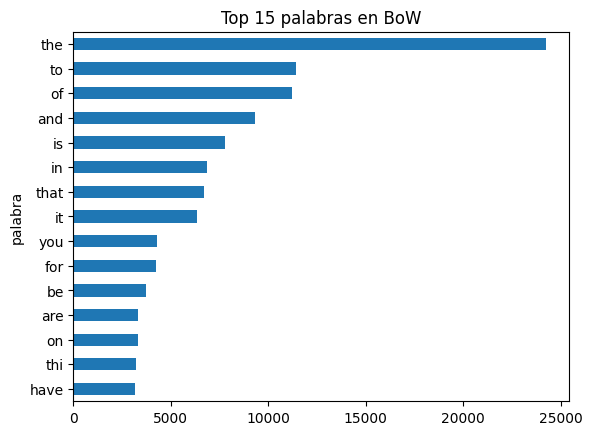

In [54]:
vectorizador_bow = CountVectorizer(max_features=15)
X_bow = vectorizador_bow.fit_transform(df['texto_limpio'])

counts = X_bow.toarray().sum(axis=0)
words = vectorizador_bow.get_feature_names_out()

# Ordenar por cantidad para el gráfico
df_bow = pd.DataFrame({'palabra': words, 'conteo': counts}).sort_values('conteo', ascending=True)

df_bow.plot.barh(x='palabra', y='conteo', legend=False)
plt.title("Top 15 palabras en BoW")
plt.show()

¿Qué problemas encontramos acá? Falta de discriminación y ruido matemático.

##### **2.3. Representación con TF-IDF (Relevancia)**

A diferencia de Bag of Words, **TF-IDF** no solo cuenta palabras. Su objetivo es identificar qué palabras son **firmas distintivas** de cada documento.

La fórmula se compone de dos partes:

1.  **TF (Term Frequency):** Cuántas veces aparece la palabra en un documento.
2.  **IDF (Inverse Document Frequency):** Penaliza las palabras que aparecen en demasiados documentos (como "the", "is", "a").

$$TF-IDF = TF \times \log\left(\frac{N}{df}\right)$$

Donde $N$ es el total de documentos y $df$ es el número de documentos que contienen la palabra. Si una palabra aparece en todos los correos, el logaritmo se vuelve 0 y el peso de la palabra se anula.

In [12]:
corpus = [
    "the rocket launched into space",
    "the rocket exploded during launch",
    "the car engine is powerful"
]

tfidf = TfidfVectorizer()

X_tfidf_small = tfidf.fit_transform(corpus)

print("Vocabulario:")
print(tfidf.get_feature_names_out())

print("\nMatriz TF-IDF:")
print(X_tfidf_small.toarray())

Vocabulario:
['car' 'during' 'engine' 'exploded' 'into' 'is' 'launch' 'launched'
 'powerful' 'rocket' 'space' 'the']

Matriz TF-IDF:
[[0.         0.         0.         0.         0.50461134 0.
  0.         0.50461134 0.         0.38376993 0.50461134 0.29803159]
 [0.         0.50461134 0.         0.50461134 0.         0.
  0.50461134 0.         0.         0.38376993 0.         0.29803159]
 [0.47952794 0.         0.47952794 0.         0.         0.47952794
  0.         0.         0.47952794 0.         0.         0.28321692]]


In [13]:
doc_vector = X_tfidf_small[0].toarray().flatten()

df_importancia = pd.DataFrame({
    "palabra": tfidf.get_feature_names_out(),
    "peso": doc_vector
})

df_importancia = df_importancia.sort_values(by="peso", ascending=False)

df_importancia.head()

,palabra,peso
7,launched,0.504611
10,space,0.504611
4,into,0.504611
9,rocket,0.383770
11,the,0.298032


Las palabras con mayor peso TF-IDF son las que mejor caracterizan el documento. Por ejemplo,`launched` y `space` tienen un peso alto. Mientras que palabras comunes como `the` tienen menor peso.

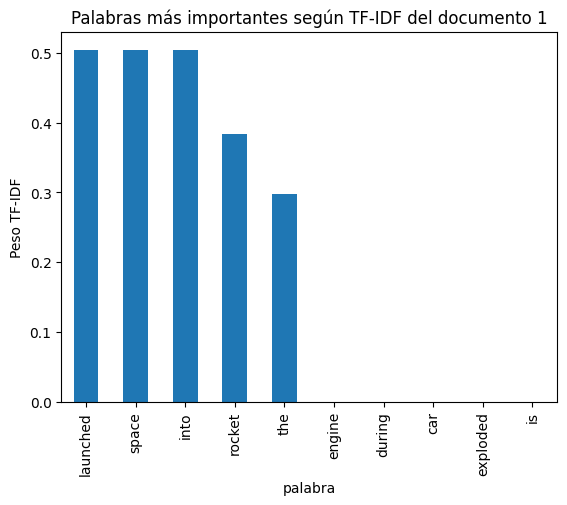

In [15]:
df_importancia.head(10).plot.bar(x="palabra", y="peso", legend=False)

plt.title("Palabras más importantes según TF-IDF del documento 1")
plt.ylabel("Peso TF-IDF")
plt.show()

Apliquémoslo ahora a nuestro dataset

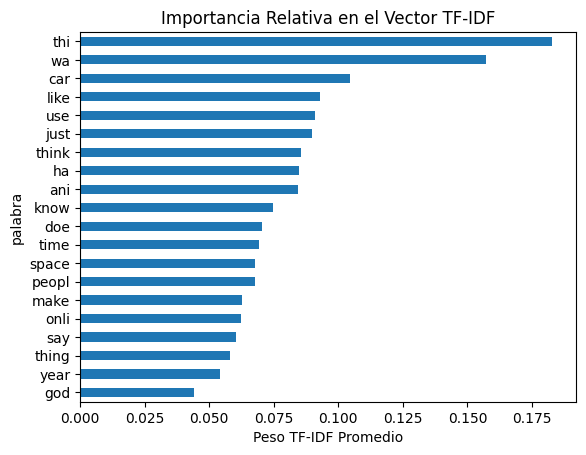

In [16]:
# Aplicamos TF-IDF al dataset
tfidf_vec = TfidfVectorizer(max_features=20, stop_words='english') # Eliminamos stopwords
X_tfidf = tfidf_vec.fit_transform(df['texto_limpio'])

# Gráfica de importancia promedio
vocab = tfidf_vec.get_feature_names_out()
pesos = X_tfidf.mean(axis=0).A1
df_resumen = pd.DataFrame({'palabra': vocab, 'peso': pesos}).sort_values('peso', ascending=True)

df_resumen.plot.barh(x='palabra', y='peso', legend=False)
plt.title("Importancia Relativa en el Vector TF-IDF")
plt.xlabel("Peso TF-IDF Promedio")
plt.show()

Al observar este gráfico, podemos apreciar el cambio. Al aplicar la penalización por frecuencia inversa (IDF), el ruido desapareció. Ahora observamos palabras clave de cada tema de noticias:
   * **`car`**: Identificador claro de la categoría `rec.autos`.
   * **`space`**: Identificador de `sci.space`.
   * **`god` / `think`**: Palabras clave de `alt.atheism`.

TF-IDF logró identificar que, aunque "the" es muy frecuente, no es **especial**. En cambio, `car` es frecuente en algunos textos pero raro en los demás, lo que la hace una característica de alto valor.

#### **Modelamiento**

##### **Modelo Base: Naive Bayes**

In [18]:
X_tfidf # Sparse

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11085 stored elements and shape (2671, 20)>

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['clase'], test_size=0.2, random_state=71, stratify=df['clase'])

En este caso usaremos Naive Bayes para la clasificación de los documentos

In [20]:
# Inicializamos modelo MultinomialNB por ser clasificación de textos
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train, y_train)

MultinomialNB()

In [25]:
y_pred = modelo_nb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.51      0.58       156
           1       0.81      0.58      0.67       188
           2       0.56      0.83      0.67       191

    accuracy                           0.65       535
   macro avg       0.68      0.64      0.64       535
weighted avg       0.68      0.65      0.65       535



##### **Búsqueda de Hiperparámetros: Naive Bayes**

Hagamos una busqueda de Hiperparametros que nos encuentre la mejor combinación para TF-IDF y para Naive Bayes.

**Importante: Como dentro de nuestro pipe vamos a agregar una nueva combinación de TF-IDF es necesario hacer un split con base en el df original y no con X_tfidf como hicimos en nuestro modelo base.**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(df['texto'], df['clase'], test_size=0.2, random_state=71, stratify=df['clase'])

In [37]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

param_grid = {
    'tfidf__max_df': [0.75, 0.9, 1.0],           # ignora palabras comunes
    'tfidf__min_df': [1, 2, 5],                  # ignora palabras muy extrañas
    'tfidf__sublinear_tf': [True, False],        # aplica log scale si es necesario
    'tfidf__stop_words':['english'],             # remover stopwords
    'nb__alpha': [0.01, 0.1, 0.5, 1.0],
    'nb__fit_prior': [True, False]
}

# Uso Randomized para no hacer 288 combinaciones sino un limite de 50
grid_search = RandomizedSearchCV(pipeline, param_grid, n_iter=50, cv=5, scoring='accuracy', n_jobs=-1, verbose=3, random_state=71)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                             ('nb', MultinomialNB())]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'nb__alpha': [0.01, 0.1, 0.5, 1.0],
                                        'nb__fit_prior': [True, False],
                                        'tfidf__max_df': [0.75, 0.9, 1.0],
                                        'tfidf__min_df': [1, 2, 5],
                                        'tfidf__stop_words': ['english'],
                                        'tfidf__sublinear_tf': [True, False]},
                   random_state=71, scoring='accuracy', verbose=3)

In [55]:
# Extraemos el mejor modelo
best_nb_model = grid_search.best_estimator_
# Resultados
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_}")

Best Parameters: {'tfidf__sublinear_tf': True, 'tfidf__stop_words': 'english', 'tfidf__min_df': 1, 'tfidf__max_df': 1.0, 'nb__fit_prior': True, 'nb__alpha': 0.5}
Best Accuracy: 0.9283777276806233


In [38]:
# Extraemos el mejor modelo
best_nb_model = grid_search.best_estimator_

# Resultados en train
y_pred = best_nb_model.predict(X_train)

print("Classification Report Train Data:")
print(classification_report(y_train, y_pred))

Classification Report Train Data:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       623
           1       0.99      0.99      0.99       749
           2       0.99      0.99      0.99       764

    accuracy                           0.99      2136
   macro avg       0.99      0.99      0.99      2136
weighted avg       0.99      0.99      0.99      2136



In [39]:
# Resultados en test
y_pred = best_nb_model.predict(X_test)
print("Classification Report Test Data:")
print(classification_report(y_test, y_pred))

Classification Report Test Data:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       156
           1       0.94      0.94      0.94       188
           2       0.91      0.93      0.92       191

    accuracy                           0.93       535
   macro avg       0.93      0.93      0.93       535
weighted avg       0.93      0.93      0.93       535



In [46]:
# Extraer los steps
tfidf_vec = best_nb_model.named_steps['tfidf']
modelo = best_nb_model.named_steps['nb']

feature_names = tfidf_vec.get_feature_names_out()
coeficientes = modelo.feature_log_prob_  # MultinomialNB usa feature_log_prob

for i, clase in enumerate(raw_data.target_names):

    top_indices = np.argsort(coeficientes[i])[-10:]

    print("\nClase:", clase)
    print("Palabras más importantes:")

    for idx in reversed(top_indices):
      log_prob = coeficientes[i][idx]
      prob = np.exp(log_prob)  # Convertimos los logs a coefs faciles de interpretar
      print(feature_names[idx], round(prob, 5))


Clase: alt.atheism
Palabras más importantes:
god 0.00111
don 0.00088
people 0.00087
think 0.00082
just 0.00073
say 0.00069
does 0.00064
believe 0.00064
religion 0.00062
said 0.00059

Clase: rec.autos
Palabras más importantes:
car 0.00181
cars 0.001
just 0.00085
like 0.00083
new 0.00074
engine 0.00072
know 0.00071
good 0.00071
don 0.0006
dealer 0.00059

Clase: sci.space
Palabras más importantes:
space 0.00137
like 0.00077
nasa 0.00075
just 0.00068
orbit 0.00067
shuttle 0.0006
don 0.00059
earth 0.00059
moon 0.00056
think 0.00056


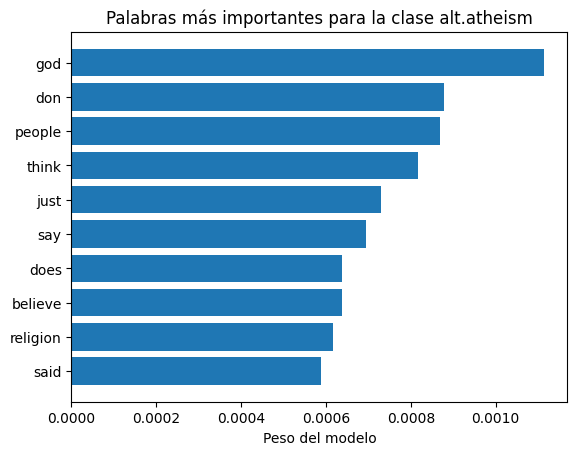

In [50]:
clase_idx = 0  # alt.atheism

top_indices = np.argsort(coeficientes[clase_idx])[-10:]

palabras = feature_names[top_indices]
pesos = np.exp(coeficientes[clase_idx][top_indices])

plt.barh(palabras, pesos)
plt.title("Palabras más importantes para la clase alt.atheism")
plt.xlabel("Peso del modelo")
plt.show()

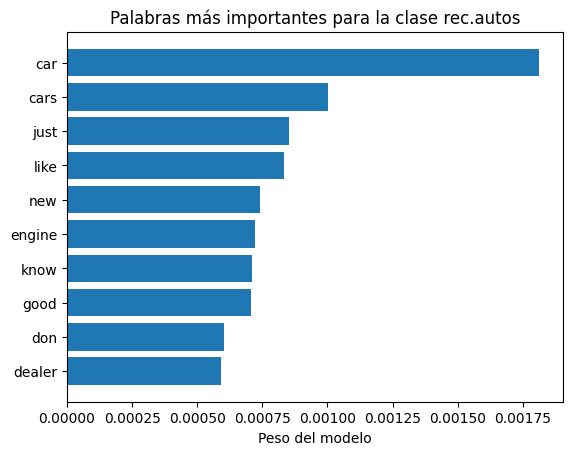

In [52]:
clase_idx = 1  # rec.autos

top_indices = np.argsort(coeficientes[clase_idx])[-10:]

palabras = feature_names[top_indices]
pesos = np.exp(coeficientes[clase_idx][top_indices])

plt.barh(palabras, pesos)
plt.title("Palabras más importantes para la clase rec.autos")
plt.xlabel("Peso del modelo")
plt.show()

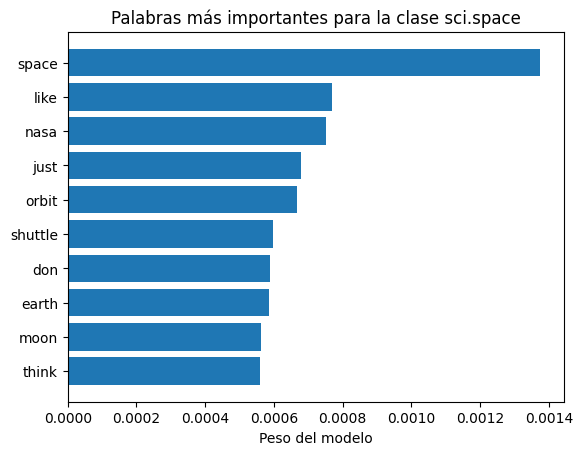

In [53]:
clase_idx = 2  # sci.space

top_indices = np.argsort(coeficientes[clase_idx])[-10:]

palabras = feature_names[top_indices]
pesos = np.exp(coeficientes[clase_idx][top_indices])

plt.barh(palabras, pesos)
plt.title("Palabras más importantes para la clase sci.space")
plt.xlabel("Peso del modelo")
plt.show()

### **3. Preguntas**

1. ¿Qué otras representaciones de texto existen y cómo funcionan?
2. Prueba otros modelos como LogisticRegression y realiza una búsqueda de hiperparámetros.